# 04 · Modelling, Evaluation & Business Insights
**Telco Customer Churn Prediction with SQL and Machine Learning**  
*Sections 9-15* · MSc Data Science project · Dr. Spoorthi H S

**In this notebook**
- Stratified split, train-only scaling and SMOTE
- Grid-searched Logistic Regression, Random Forest and XGBoost
- Test comparison: F1 ≈ 0.62-0.63, ROC-AUC 0.84, recall 74-79 %
- Feature importance, feature-engineering impact and retention recommendations

> **How to use these notebooks.** The outputs below come from one complete run in Google Colab. Each part builds on objects created earlier (the SQL database, the prepared DataFrame, trained models), so the part notebooks are for reading and review. To reproduce the results, run [`00_full_pipeline_run_all.ipynb`](00_full_pipeline_run_all.ipynb) top to bottom.

[← Feature Engineering & Exploratory Analysis](03_feature_engineering_and_eda.ipynb)

---

## 9. DATA PREPARATION FOR MACHINE LEARNING

In [55]:
# Prepare features and target
X = df.drop(['Churn', 'customerID'], axis=1)
y = df['Churn']

print(f'Features: {X.shape[1]}, Samples: {X.shape[0]}')
print(f'\nChurn Distribution:')
print(y.value_counts())
print(f'\nChurn Rate: {y.mean():.2%}')

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Handle class imbalance
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f'\nTraining set: {X_train_scaled.shape}')
print(f'After SMOTE: {X_train_smote.shape}')


Features: 36, Samples: 7043

Churn Distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn Rate: 26.54%

Training set: (4507, 36)
After SMOTE: (6622, 36)


> **Note on the split.** Data are split 64 / 16 / 20 (train / validation / test), stratified on churn. The scaler and SMOTE are fitted on the training split only, so no information from the test set leaks into training. The validation split is created but not used in this notebook; it is available for threshold tuning in future work.

## 10. MACHINE LEARNING MODELS

In [56]:
print('Model 1: Logistic Regression')
param_grid_lr = {'C': [0.001, 0.01, 0.1, 1, 10], 'penalty': ['l1', 'l2']}
lr = LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')
gs_lr = GridSearchCV(lr, param_grid_lr, cv=5, scoring='f1')
gs_lr.fit(X_train_smote, y_train_smote)
lr_best = gs_lr.best_estimator_
print(f'Best params: {gs_lr.best_params_}')
print(f'CV F1 Score: {gs_lr.best_score_:.4f}')

y_pred_lr = lr_best.predict(X_test_scaled)
y_pred_proba_lr = lr_best.predict_proba(X_test_scaled)[:, 1]
print('\n✓ Logistic Regression trained')


Model 1: Logistic Regression
Best params: {'C': 0.01, 'penalty': 'l2'}
CV F1 Score: 0.7909

✓ Logistic Regression trained


In [57]:
print('Model 2: Random Forest')
param_grid_rf = {'n_estimators': [100, 200], 'max_depth': [10, 20], 'min_samples_split': [5, 10]}
rf = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')
gs_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='f1')
gs_rf.fit(X_train_scaled, y_train)
rf_best = gs_rf.best_estimator_
print(f'Best params: {gs_rf.best_params_}')
print(f'CV F1 Score: {gs_rf.best_score_:.4f}')

y_pred_rf = rf_best.predict(X_test_scaled)
y_pred_proba_rf = rf_best.predict_proba(X_test_scaled)[:, 1]
print('\n✓ Random Forest trained')


Model 2: Random Forest
Best params: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}
CV F1 Score: 0.6339

✓ Random Forest trained


In [58]:
print('Model 3: XGBoost')
scale_pos = (len(y_train) - y_train.sum()) / y_train.sum()
param_grid_xgb = {'n_estimators': [100, 200], 'max_depth': [4, 6], 'learning_rate': [0.01, 0.1]}
xgb_model = xgb.XGBClassifier(random_state=42, scale_pos_weight=scale_pos, eval_metric='logloss', use_label_encoder=False)
gs_xgb = GridSearchCV(xgb_model, param_grid_xgb, cv=5, scoring='f1')
gs_xgb.fit(X_train_scaled, y_train)
xgb_best = gs_xgb.best_estimator_
print(f'Best params: {gs_xgb.best_params_}')
print(f'CV F1 Score: {gs_xgb.best_score_:.4f}')

y_pred_xgb = xgb_best.predict(X_test_scaled)
y_pred_proba_xgb = xgb_best.predict_proba(X_test_scaled)[:, 1]
print('\n✓ XGBoost trained')


Model 3: XGBoost
Best params: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 200}
CV F1 Score: 0.6287

✓ XGBoost trained


> **Reading the CV scores.** Logistic Regression's cross-validated F1 (0.79) is computed on SMOTE-balanced training data, where half the samples are churners and some are synthetic, so it is not comparable with the Random Forest and XGBoost CV scores (≈ 0.63), which use the real class balance. The test-set comparison in Section 11 is the fair one.

## 11. MODEL PERFORMANCE COMPARISON


Model Performance Comparison:
     Accuracy  Precision  Recall      F1     AUC
LR     0.7502     0.5198  0.7727  0.6215  0.8441
RF     0.7665     0.5446  0.7353  0.6257  0.8376
XGB    0.7452     0.5130  0.7941  0.6233  0.8423


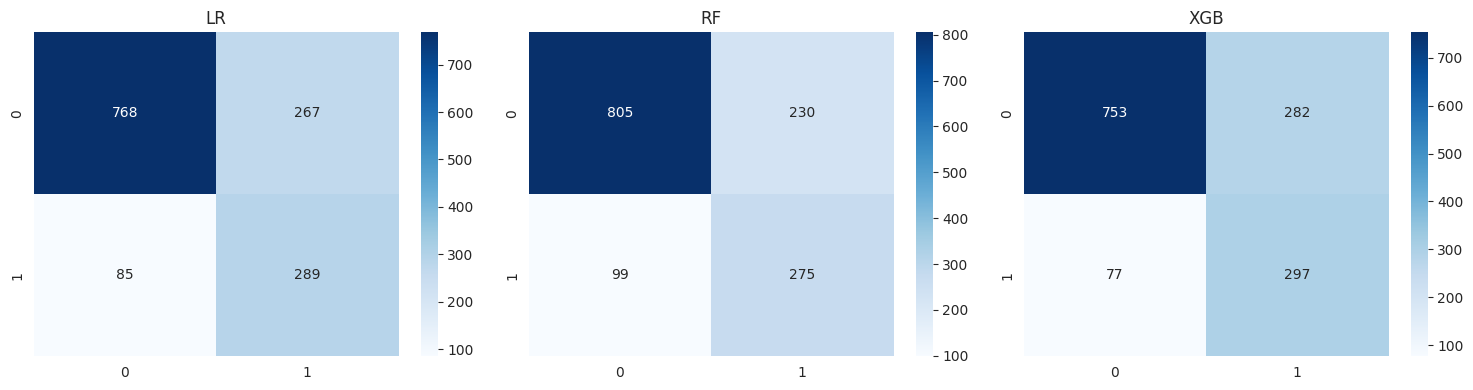

✓ Model Comparison Complete


In [59]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

# Evaluation metrics
results = {}
for name, y_pred, y_proba in [('LR', y_pred_lr, y_pred_proba_lr),
                                ('RF', y_pred_rf, y_pred_proba_rf),
                                ('XGB', y_pred_xgb, y_pred_proba_xgb)]:
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_proba)
    }

comp_df = pd.DataFrame(results).T
print('\nModel Performance Comparison:')
print(comp_df.round(4))

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, (name, y_pred) in enumerate([('LR', y_pred_lr), ('RF', y_pred_rf), ('XGB', y_pred_xgb)]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[idx], cmap='Blues')
    axes[idx].set_title(f'{name}')
plt.tight_layout()
plt.show()
print('✓ Model Comparison Complete')


> **Interpretation.** On the 1,409-customer test set the three models are practically tied: F1 0.622-0.626 and ROC-AUC 0.838-0.844. Random Forest has the highest F1 (0.626) and accuracy (76.7 %); Logistic Regression has the best AUC (0.844); XGBoost has the highest recall (79.4 %). Because all were tuned for F1 with class balancing, they deliberately trade precision (≈ 0.52) for recall, catching three out of four churners at the cost of some false alarms - usually the right trade-off when a retention offer is cheaper than a lost customer.

## 12. FEATURE IMPORTANCE ANALYSIS

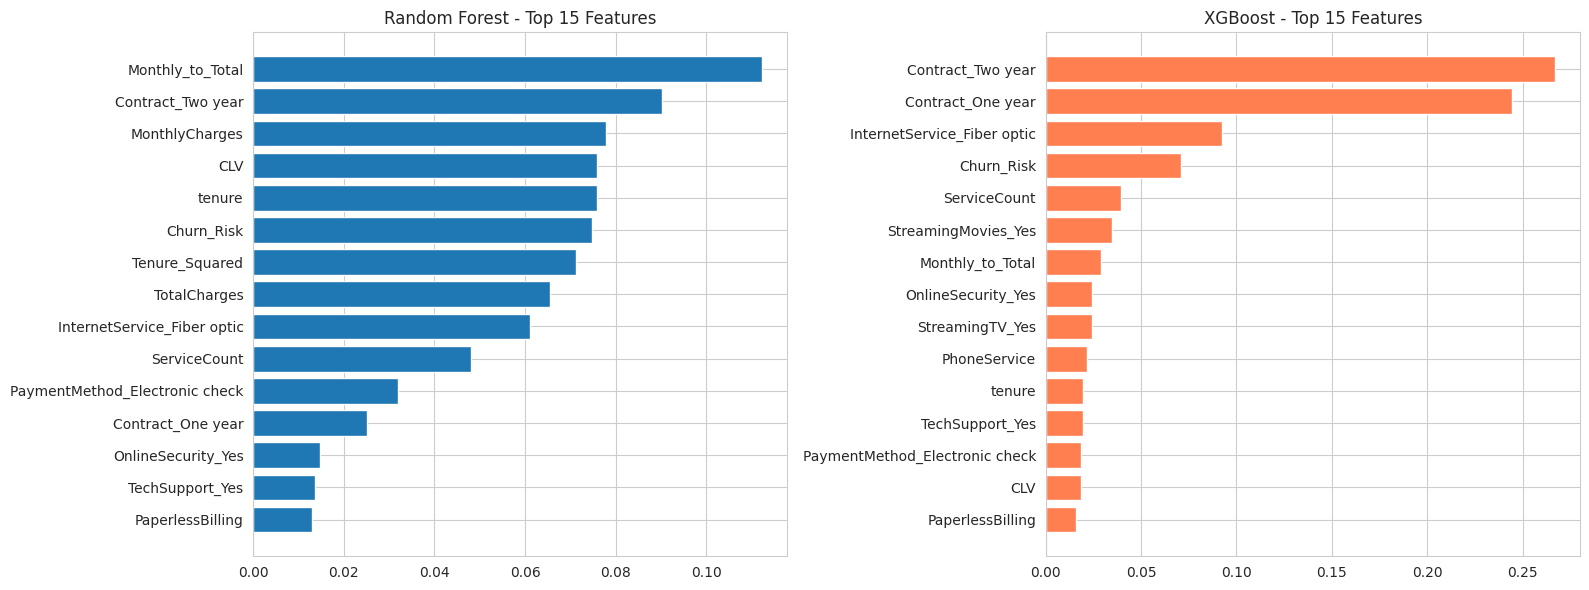

✓ Feature Importance Complete


In [60]:
# Feature importance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest
rf_imp = pd.DataFrame({'Feature': X_train.columns, 'Importance': rf_best.feature_importances_}).sort_values('Importance', ascending=False).head(15)
axes[0].barh(range(len(rf_imp)), rf_imp['Importance'].values)
axes[0].set_yticks(range(len(rf_imp)))
axes[0].set_yticklabels(rf_imp['Feature'].values)
axes[0].set_title('Random Forest - Top 15 Features')
axes[0].invert_yaxis()

# XGBoost
xgb_imp = pd.DataFrame({'Feature': X_train.columns, 'Importance': xgb_best.feature_importances_}).sort_values('Importance', ascending=False).head(15)
axes[1].barh(range(len(xgb_imp)), xgb_imp['Importance'].values, color='coral')
axes[1].set_yticks(range(len(xgb_imp)))
axes[1].set_yticklabels(xgb_imp['Feature'].values)
axes[1].set_title('XGBoost - Top 15 Features')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()
print('✓ Feature Importance Complete')


## 13. FEATURE ENGINEERING IMPACT ANALYSIS


Feature Engineering Impact:
              Model  Accuracy      F1
0     RF (Original)    0.7615  0.5862
1   RF (Engineered)    0.7665  0.6257
2    XGB (Original)    0.7885  0.5270
3  XGB (Engineered)    0.7452  0.6233


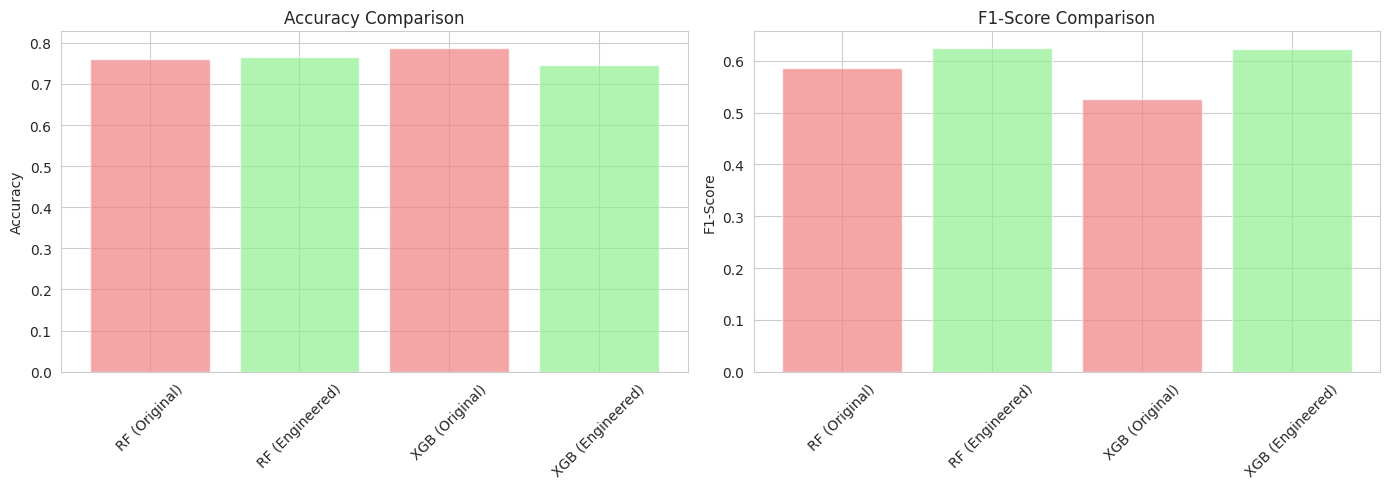

✓ Feature Engineering Impact Complete


In [61]:
# Compare with original features
original_cols = [col for col in ['tenure', 'SeniorCitizen', 'MonthlyCharges', 'TotalCharges', 'gender', 'Partner'] if col in X_train.columns]
X_train_orig = X_train_scaled[original_cols]
X_test_orig = X_test_scaled[original_cols]

# Train RF and XGB with original features
rf_orig = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')
rf_orig.fit(X_train_orig, y_train)
y_pred_rf_orig = rf_orig.predict(X_test_orig)

xgb_orig = xgb.XGBClassifier(n_estimators=100, max_depth=4, random_state=42, eval_metric='logloss', use_label_encoder=False)
xgb_orig.fit(X_train_orig, y_train)
y_pred_xgb_orig = xgb_orig.predict(X_test_orig)

# Compare
fe_comp = pd.DataFrame({
    'Model': ['RF (Original)', 'RF (Engineered)', 'XGB (Original)', 'XGB (Engineered)'],
    'Accuracy': [accuracy_score(y_test, y_pred_rf_orig), accuracy_score(y_test, y_pred_rf),
                 accuracy_score(y_test, y_pred_xgb_orig), accuracy_score(y_test, y_pred_xgb)],
    'F1': [f1_score(y_test, y_pred_rf_orig), f1_score(y_test, y_pred_rf),
           f1_score(y_test, y_pred_xgb_orig), f1_score(y_test, y_pred_xgb)]
})

print('\nFeature Engineering Impact:')
print(fe_comp.round(4))

# Visualization
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].bar(fe_comp['Model'], fe_comp['Accuracy'], color=['lightcoral', 'lightgreen', 'lightcoral', 'lightgreen'], alpha=0.7)
ax[0].set_ylabel('Accuracy')
ax[0].set_title('Accuracy Comparison')
ax[0].tick_params(axis='x', rotation=45)

ax[1].bar(fe_comp['Model'], fe_comp['F1'], color=['lightcoral', 'lightgreen', 'lightcoral', 'lightgreen'], alpha=0.7)
ax[1].set_ylabel('F1-Score')
ax[1].set_title('F1-Score Comparison')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
print('✓ Feature Engineering Impact Complete')


> **Caveat.** The "original" baseline here uses only six raw columns, and the original XGBoost model has no class weighting, so this comparison measures the value of the full encoded and engineered feature set together rather than the engineered features alone. The F1 gains (+0.040 for Random Forest, +0.096 for XGBoost) are real, but XGBoost's accuracy falls (0.789 → 0.745) because class weighting shifts it toward catching more churners.

## 14. BUSINESS INSIGHTS & RECOMMENDATIONS

In [62]:
print('='*80)
print('KEY BUSINESS INSIGHTS')
print('='*80)

print('\n1. CHURN PATTERNS:')
print(f'   - Overall Churn Rate: {y.mean():.2%}')
print(f'   - Early Churn (<6mo): {df[df.tenure < 6]["Churn"].mean():.2%}')
print(f'   - Loyal Customers (24+mo): {df[df.tenure >= 24]["Churn"].mean():.2%}')

print('\n2. MODEL PERFORMANCE:')
best_idx = comp_df['F1'].idxmax()
print(f'   - Best Model: {best_idx}')
print(f'   - F1-Score: {comp_df.loc[best_idx, "F1"]:.4f}')
print(f'   - Recall: {comp_df.loc[best_idx, "Recall"]:.4f}')

print('\n3. FEATURE ENGINEERING IMPACT:')
rf_improve = (fe_comp.loc[1, 'F1'] - fe_comp.loc[0, 'F1']) * 100
xgb_improve = (fe_comp.loc[3, 'F1'] - fe_comp.loc[2, 'F1']) * 100
print(f'   - RF F1 Improvement: {rf_improve:+.2f}%')
print(f'   - XGB F1 Improvement: {xgb_improve:+.2f}%')

print('\n4. RETENTION RECOMMENDATIONS:')
print('   - Focus on first 6 months of customer lifecycle')
print('   - Increase service bundling to boost adoption')
print('   - Offer contract incentives (month-to-month -> annual)')
print('   - Monitor high-risk segments proactively')

print('\n' + '='*80)
print('ANALYSIS COMPLETE')
print('='*80)


KEY BUSINESS INSIGHTS

1. CHURN PATTERNS:
   - Overall Churn Rate: 26.54%
   - Early Churn (<6mo): 54.27%
   - Loyal Customers (24+mo): 14.29%

2. MODEL PERFORMANCE:
   - Best Model: RF
   - F1-Score: 0.6257
   - Recall: 0.7353

3. FEATURE ENGINEERING IMPACT:
   - RF F1 Improvement: +3.95%
   - XGB F1 Improvement: +9.63%

4. RETENTION RECOMMENDATIONS:
   - Focus on first 6 months of customer lifecycle
   - Increase service bundling to boost adoption
   - Offer contract incentives (month-to-month -> annual)
   - Monitor high-risk segments proactively

ANALYSIS COMPLETE


## 15. CONCLUSIONS & NEXT STEPS

- **Who churns:** customers in their first six months (54 % churn) and customers on month-to-month contracts (43 % churn, against 11 % on one-year and 3 % on two-year contracts, from the Query 3 output); customers with 24+ months of tenure churn at only 14 %. Month-to-month fibre-optic customers are the riskiest segment (55 % churn).
- **Model performance:** Logistic Regression, Random Forest and XGBoost reach F1 ≈ 0.62-0.63 and ROC-AUC ≈ 0.84 on held-out data, recovering 74-79 % of churners. The simplest model (Logistic Regression) is as good as the ensembles and is the easiest to explain to a business audience.
- **Next steps:** use the validation split to tune the decision threshold against the cost of a retention offer, add cross-validated confidence intervals, and explain individual predictions with SHAP for targeted retention campaigns.

---

[← Feature Engineering & Exploratory Analysis](03_feature_engineering_and_eda.ipynb) · **End of the project.** [Back to the start →](01_data_and_sql_pipeline.ipynb)